In [1]:
%cd ..
# change this so that it navigates to root folder

/home/mille/dac_test


In [2]:
#@title Imports

from pathlib import Path

import torch
import torchaudio
from IPython.display import Audio
import dac
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
#@title Download and load DAC model

device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = dac.utils.download()
model = dac.DAC.load(model_path)
model = model.to(device)

/home/mille/miniconda3/envs/dac/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
# Load the audio file

def load_mono(file_name, target_sr):
    audio, sr = torchaudio.load(file_name)
    if audio.shape[0] > 1:
        audio = audio.mean(0, keepdim=True)

    if sr != target_sr:
        audio = torchaudio.functional.resample(audio, sr, target_sr)
        sr = target_sr
    audio = audio.clamp(-1, 1)
    return audio

target_sr = model.sample_rate  # Target sample rate to match the model's requirements

audio = load_mono("training_data/violin.wav", target_sr).to(device)
with torch.inference_mode():
    embeddings = model.encode(audio.unsqueeze(0))[0]

In [5]:
stretched_embeddings = torch.nn.functional.interpolate(embeddings, scale_factor=2, mode="linear")

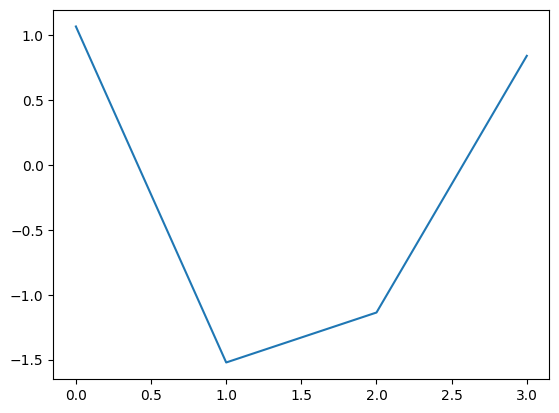

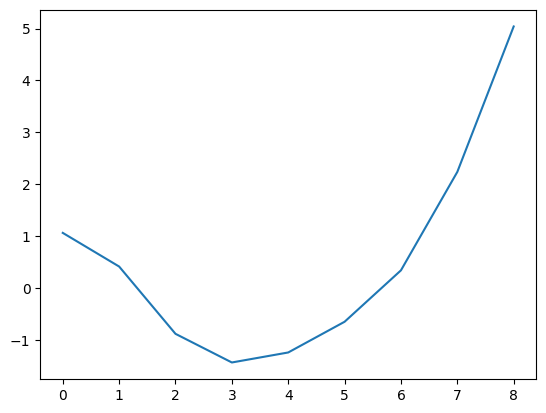

In [6]:
plt.plot(embeddings[0,0,0:4])
plt.figure()
plt.plot(stretched_embeddings[0,0,0:9])

In [7]:
with torch.inference_mode():
    # stretched_embeddings = model.quantizer(stretched_embeddings, None)[0]
    stretched_audio = model.decode(stretched_embeddings[:,:,:1000])[0]

In [9]:
display(Audio(audio[0].detach().cpu().numpy(), rate=target_sr))
display(Audio(stretched_audio[0].detach().cpu().numpy(), rate=target_sr))

In [8]:
display(Audio(stretched_audio[0].detach().cpu().numpy(), rate=target_sr))

In [10]:
torchaudio.save("training_data/violin_stretch.flac", stretched_audio, target_sr)